# Bank Marketing Analytics & Subscription Prediction

## 04 — Statistical Analysis

This notebook evaluates selected relationships in the UCI Bank Marketing dataset using inferential statistics and effect-size measures.

### Objectives

- Test associations between categorical features and subscription outcome.
- Compare numerical distributions between subscribers and non-subscribers.
- Correct for multiple statistical tests.
- Report effect sizes in addition to p-values.
- Estimate confidence intervals for the overall subscription rate.
- Estimate selected differences in subscription proportions.
- distinguish observational analysis from randomized experimentation.
- document the leakage-sensitive interpretation of call duration.

> This dataset is observational. Statistical association does not establish causation.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


def locate_project_root(start_path: Path) -> Path:
    """Locate the project root from the notebook directory."""
    current_path = start_path.resolve()

    for candidate in [current_path, *current_path.parents]:
        expected_script = (
            candidate
            / "src"
            / "statistical_analysis.py"
        )

        if expected_script.exists():
            return candidate

    raise FileNotFoundError(
        "Project root could not be located. "
        "Run the notebook from inside the project."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from src.statistical_analysis import (
    ALPHA,
    CATEGORICAL_FEATURES,
    CONFIDENCE_LEVEL,
    NUMERICAL_TEST_SPECIFICATIONS,
    OUTPUT_DIRECTORY,
    TARGET_COLUMN,
    build_confidence_interval_reports,
    load_analysis_data,
    run_categorical_association_tests,
    run_numerical_group_tests,
    validate_results,
)


pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.6f}".format)

sns.set_theme(style="whitegrid")

print(f"Project root: {PROJECT_ROOT}")
print(f"Statistical reports: {OUTPUT_DIRECTORY}")
print(f"Significance level: {ALPHA}")
print(f"Confidence level: {CONFIDENCE_LEVEL}")

Project root: C:\Users\omary\Documents\VS Code\bank-marketing-analytics-ml
Statistical reports: C:\Users\omary\Documents\VS Code\bank-marketing-analytics-ml\reports\statistics
Significance level: 0.05
Confidence level: 0.95


## 1. Load and Validate the Analysis Dataset

The cleaned dataset contains 45,211 campaign records.

A derived categorical feature named `previously_contacted` is created:

- `no`: `pdays = -1`, meaning no previous campaign contact.
- `yes`: `pdays >= 0`, meaning a previous contact was recorded.

This avoids treating the sentinel value `-1` as an ordinary elapsed-day value.

In [2]:
data = load_analysis_data()

print(f"Analysis dataset shape: {data.shape}")
print(f"Subscribers: {int(data[TARGET_COLUMN].sum())}")
print(
    "Non-subscribers:",
    int((data[TARGET_COLUMN] == 0).sum()),
)

display(data.head())

Analysis dataset shape: (45211, 18)
Subscribers: 5289
Non-subscribers: 39922


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed,previously_contacted
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0,no


## 2. Statistical-Analysis Design

### Categorical features

Categorical features are evaluated with the **Chi-square Test of Independence**.

- Null hypothesis: the feature and subscription outcome are independent.
- Alternative hypothesis: the feature and subscription outcome are associated.

Because a large sample can produce very small p-values for weak relationships, **Cramér's V** is also reported as an effect-size measure.

### Numerical features

Numerical distributions are compared using the **Mann–Whitney U test**.

This non-parametric test is appropriate because several numerical variables are highly skewed and contain extreme or zero-inflated values.

**Rank-biserial correlation** is reported as the numerical effect size.

### Multiple testing

Benjamini–Hochberg correction is applied separately to the categorical and numerical test families to control the False Discovery Rate.

In [3]:
categorical_results = (
    run_categorical_association_tests(data)
)

numerical_results = (
    run_numerical_group_tests(data)
)

(
    overall_interval,
    comparison_intervals,
) = build_confidence_interval_reports(data)

validate_results(
    categorical_results=categorical_results,
    numerical_results=numerical_results,
    overall_interval=overall_interval,
    comparison_intervals=comparison_intervals,
)

print(
    "All statistical-analysis results "
    "were generated and validated successfully."
)

All statistical-analysis results were generated and validated successfully.


## 3. Categorical Associations with Subscription

The following table is ordered by Cramér's V rather than by p-value.

This is important because:

- P-values quantify evidence against independence.
- Cramér's V describes the strength of the observed association.
- With 45,211 records, even small associations may be statistically significant.

In [4]:
categorical_display_columns = [
    "feature",
    "number_of_categories",
    "chi_square_statistic",
    "adjusted_p_value_bh",
    "cramers_v",
    "effect_size_interpretation",
    "reject_null_fdr_0_05",
    "assumption_warning",
]

display(
    categorical_results[
        categorical_display_columns
    ]
)

,feature,number_of_categories,chi_square_statistic,adjusted_p_value_bh,cramers_v,effect_size_interpretation,reject_null_fdr_0_05,assumption_warning
0,poutcome,4,"4,391.506589",0.000000,0.311663,Moderate,True,False
1,month,12,"3,061.838938",0.000000,0.260237,Small,True,False
2,previously_contacted,2,"1,264.870780",0.000000,0.167263,Small,True,False
3,contact,3,"1,035.714225",0.000000,0.151355,Small,True,False
4,housing,2,875.693718,0.000000,0.139173,Small,True,False
5,job,12,836.105488,0.000000,0.135990,Small,True,False
6,education,4,238.923506,0.000000,0.072695,Negligible,True,False
7,loan,2,210.194934,0.000000,0.068185,Negligible,True,False
8,marital,3,196.495946,0.000000,0.065926,Negligible,True,False
9,default,2,22.723502,0.000002,0.022419,Negligible,True,False


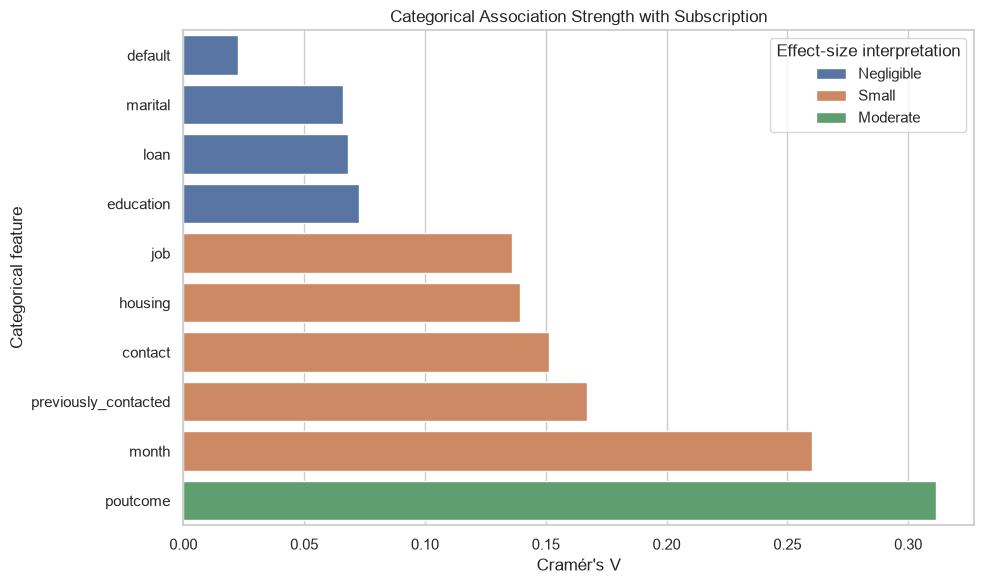

In [5]:
categorical_plot_data = (
    categorical_results
    .sort_values(
        "cramers_v",
        ascending=True,
    )
)

figure, axis = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=categorical_plot_data,
    x="cramers_v",
    y="feature",
    hue="effect_size_interpretation",
    dodge=False,
    ax=axis,
)

axis.set_title(
    "Categorical Association Strength with Subscription"
)
axis.set_xlabel("Cramér's V")
axis.set_ylabel("Categorical feature")
axis.legend(title="Effect-size interpretation")

plt.tight_layout()
plt.show()

In [6]:
categorical_significance_summary = (
    categorical_results
    .groupby(
        [
            "reject_null_fdr_0_05",
            "effect_size_interpretation",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="number_of_features")
)

display(categorical_significance_summary)

,reject_null_fdr_0_05,effect_size_interpretation,number_of_features
0,True,Moderate,1
1,True,Negligible,4
2,True,Small,5


### Interpretation of the Categorical Tests

A rejected null hypothesis indicates evidence of an association between the feature and subscription outcome after multiple-testing correction.

It does not mean:

- The feature causes the client to subscribe.
- Every category difference is operationally important.
- The feature will necessarily be useful in a predictive model.

Effect size, segment size, business context, and multivariable modeling must also be considered.

## 4. Numerical Comparisons Between Subscribers and Non-Subscribers

The Mann–Whitney U tests compare the distributions of numerical variables between the two independent target groups.

The test is not simply a test of means or medians. It evaluates whether values from one group tend to rank higher or lower than values from the other group.

Rank-biserial correlation direction:

- Positive: values tend to be higher among subscribers.
- Negative: values tend to be lower among subscribers.
- Near zero: little distributional separation.

In [7]:
numerical_display_columns = [
    "analysis_name",
    "subset",
    "subscriber_sample_size",
    "non_subscriber_sample_size",
    "subscriber_median",
    "non_subscriber_median",
    "median_difference",
    "adjusted_p_value_bh",
    "rank_biserial_correlation",
    "effect_size_interpretation",
    "reject_null_fdr_0_05",
    "leakage_sensitive",
]

display(
    numerical_results[
        numerical_display_columns
    ]
)

,analysis_name,subset,subscriber_sample_size,non_subscriber_sample_size,subscriber_median,non_subscriber_median,median_difference,adjusted_p_value_bh,rank_biserial_correlation,effect_size_interpretation,reject_null_fdr_0_05,leakage_sensitive
0,duration,all_clients,5289,39922,426.000000,164.000000,262.000000,0.000000,0.615191,Large,True,True
1,pdays_previously_contacted,previously_contacted_clients,1905,6352,181.000000,232.000000,-51.000000,0.000000,-0.255166,Small,True,False
2,previous,all_clients,5289,39922,0.000000,0.000000,0.000000,0.000000,0.204607,Small,True,False
3,balance,all_clients,5289,39922,733.000000,417.000000,316.000000,0.000000,0.180123,Small,True,False
4,campaign,all_clients,5289,39922,2.000000,2.000000,0.000000,0.000000,-0.144668,Small,True,False
5,age,all_clients,5289,39922,38.000000,39.000000,-1.000000,0.062818,-0.015711,Negligible,False,False


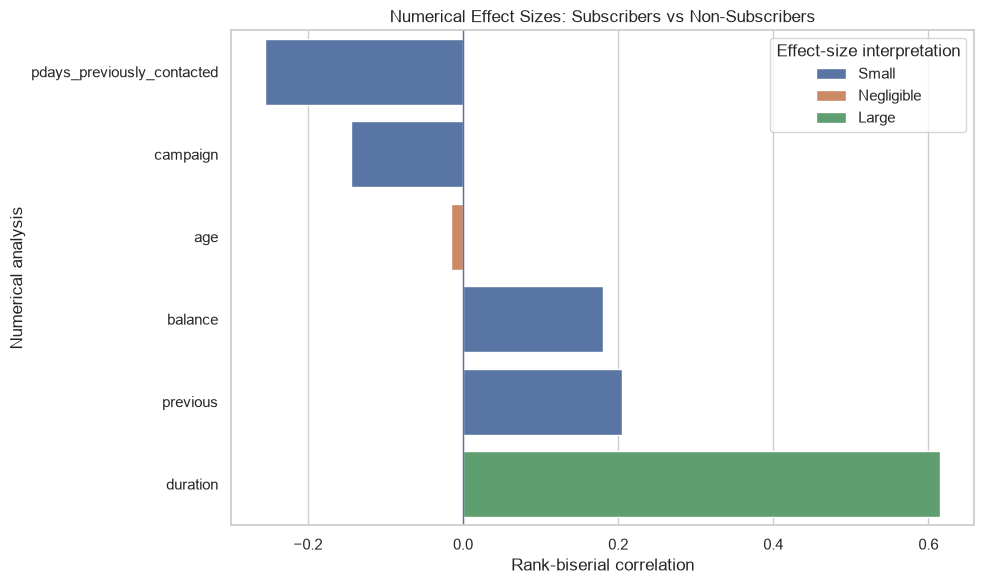

In [8]:
numerical_plot_data = (
    numerical_results
    .sort_values(
        "rank_biserial_correlation",
        ascending=True,
    )
)

figure, axis = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=numerical_plot_data,
    x="rank_biserial_correlation",
    y="analysis_name",
    hue="effect_size_interpretation",
    dodge=False,
    ax=axis,
)

axis.axvline(
    0,
    linewidth=1,
)

axis.set_title(
    "Numerical Effect Sizes: Subscribers vs Non-Subscribers"
)
axis.set_xlabel("Rank-biserial correlation")
axis.set_ylabel("Numerical analysis")
axis.legend(title="Effect-size interpretation")

plt.tight_layout()
plt.show()

In [9]:
numerical_inference_summary = (
    numerical_results[
        [
            "analysis_name",
            "adjusted_p_value_bh",
            "reject_null_fdr_0_05",
            "rank_biserial_correlation",
            "effect_size_interpretation",
            "median_direction",
        ]
    ]
    .copy()
)

display(numerical_inference_summary)

,analysis_name,adjusted_p_value_bh,reject_null_fdr_0_05,rank_biserial_correlation,effect_size_interpretation,median_direction
0,duration,0.000000,True,0.615191,Large,Higher among subscribers
1,pdays_previously_contacted,0.000000,True,-0.255166,Small,Lower among subscribers
2,previous,0.000000,True,0.204607,Small,Equal medians
3,balance,0.000000,True,0.180123,Small,Higher among subscribers
4,campaign,0.000000,True,-0.144668,Small,Equal medians
5,age,0.062818,False,-0.015711,Negligible,Lower among subscribers


### Call Duration and Temporal Data Leakage

Call duration is expected to show one of the strongest associations with subscription.

However, duration is only known after the marketing call ends.

Therefore:

- It is valid for retrospective descriptive analysis.
- It may help explain completed campaign outcomes.
- It must be excluded from the primary pre-call targeting model.
- A predictive model containing duration would use information unavailable at the real decision point.

Statistical importance does not override deployment-time feature availability.

In [10]:
assert len(data) == 45_211

assert len(categorical_results) == len(
    CATEGORICAL_FEATURES
)

assert len(numerical_results) == len(
    NUMERICAL_TEST_SPECIFICATIONS
)

assert categorical_results[
    "adjusted_p_value_bh"
].between(0, 1).all()

assert numerical_results[
    "adjusted_p_value_bh"
].between(0, 1).all()

assert categorical_results[
    "cramers_v"
].between(0, 1).all()

assert numerical_results[
    "rank_biserial_correlation"
].between(-1, 1).all()

assert (
    numerical_results.loc[
        numerical_results[
            "analysis_name"
        ] == "duration",
        "leakage_sensitive",
    ].iloc[0]
)

print(
    "Statistical notebook setup, categorical tests, "
    "and numerical tests passed successfully."
)

Statistical notebook setup, categorical tests, and numerical tests passed successfully.


## 5. Overall Subscription-Rate Confidence Interval

The observed subscription rate is a sample estimate.

A 95% Wilson score interval is used to quantify the uncertainty around the overall subscription proportion.

The Wilson interval is preferred over the simple normal approximation because it generally provides better coverage for proportion estimates.

In [11]:
display(overall_interval)

,total_clients,subscribers,estimated_subscription_rate_percentage,ci_lower_percentage,ci_upper_percentage,confidence_level,method
0,45211,5289,11.698480,11.405468,11.998001,0.950000,Wilson score interval


In [12]:
overall_result = overall_interval.iloc[0]

estimated_rate = float(
    overall_result[
        "estimated_subscription_rate_percentage"
    ]
)

ci_lower = float(
    overall_result["ci_lower_percentage"]
)

ci_upper = float(
    overall_result["ci_upper_percentage"]
)

print(f"Estimated subscription rate: {estimated_rate:.2f}%")
print(
    f"95% confidence interval: "
    f"{ci_lower:.2f}% to {ci_upper:.2f}%"
)

Estimated subscription rate: 11.70%
95% confidence interval: 11.41% to 12.00%


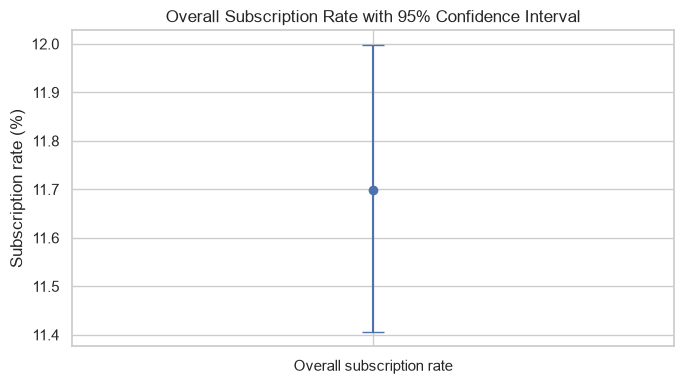

In [13]:
error_bars = np.array(
    [
        [estimated_rate - ci_lower],
        [ci_upper - estimated_rate],
    ]
)

figure, axis = plt.subplots(figsize=(7, 4))

axis.errorbar(
    x=["Overall subscription rate"],
    y=[estimated_rate],
    yerr=error_bars,
    fmt="o",
    capsize=8,
)

axis.set_title(
    "Overall Subscription Rate with 95% Confidence Interval"
)
axis.set_xlabel("")
axis.set_ylabel("Subscription rate (%)")

plt.tight_layout()
plt.show()

### Confidence-Interval Interpretation

The estimated subscription rate is approximately 11.7%.

The 95% confidence interval describes the uncertainty around this estimated population proportion under the assumptions of the sampling procedure.

It does not mean that 95% of individual customers have subscription probabilities inside this interval.

## 6. Selected Differences in Subscription Proportions

Selected customer and campaign groups are compared using differences in subscription rates.

The reported quantity is measured in **percentage points**, not relative percentage change.

For example, a difference from 4% to 15% is:

- An 11-percentage-point difference.
- Not simply an 11% relative increase.

These intervals describe observed group differences, not causal treatment effects.

In [14]:
comparison_display_columns = [
    "comparison",
    "group_a",
    "group_b",
    "group_a_size",
    "group_b_size",
    "group_a_rate_percentage",
    "group_b_rate_percentage",
    "difference_percentage_points",
    "ci_lower_percentage_points",
    "ci_upper_percentage_points",
]

display(
    comparison_intervals[
        comparison_display_columns
    ]
)

,comparison,group_a,group_b,group_a_size,group_b_size,group_a_rate_percentage,group_b_rate_percentage,difference_percentage_points,ci_lower_percentage_points,ci_upper_percentage_points
0,Previous success vs other outcomes,Previous outcome: success,Other previous outcomes,1511,43700,64.725347,9.864989,54.860359,52.434927,57.285790
1,Cellular vs unknown contact,Cellular contact,Unknown contact,29285,13020,14.918900,4.070661,10.848240,10.317471,11.379009
2,One campaign contact vs multiple contacts,One campaign contact,Multiple campaign contacts,17544,27667,14.597583,9.860122,4.737461,4.107876,5.367046


In [15]:
comparison_plot_data = (
    comparison_intervals
    .copy()
)

comparison_plot_data["lower_error"] = (
    comparison_plot_data[
        "difference_percentage_points"
    ]
    - comparison_plot_data[
        "ci_lower_percentage_points"
    ]
)

comparison_plot_data["upper_error"] = (
    comparison_plot_data[
        "ci_upper_percentage_points"
    ]
    - comparison_plot_data[
        "difference_percentage_points"
    ]
)

comparison_plot_data = (
    comparison_plot_data
    .sort_values(
        "difference_percentage_points",
        ascending=True,
    )
    .reset_index(drop=True)
)

display(
    comparison_plot_data[
        [
            "comparison",
            "difference_percentage_points",
            "ci_lower_percentage_points",
            "ci_upper_percentage_points",
        ]
    ]
)

,comparison,difference_percentage_points,ci_lower_percentage_points,ci_upper_percentage_points
0,One campaign contact vs multiple contacts,4.737461,4.107876,5.367046
1,Cellular vs unknown contact,10.848240,10.317471,11.379009
2,Previous success vs other outcomes,54.860359,52.434927,57.285790


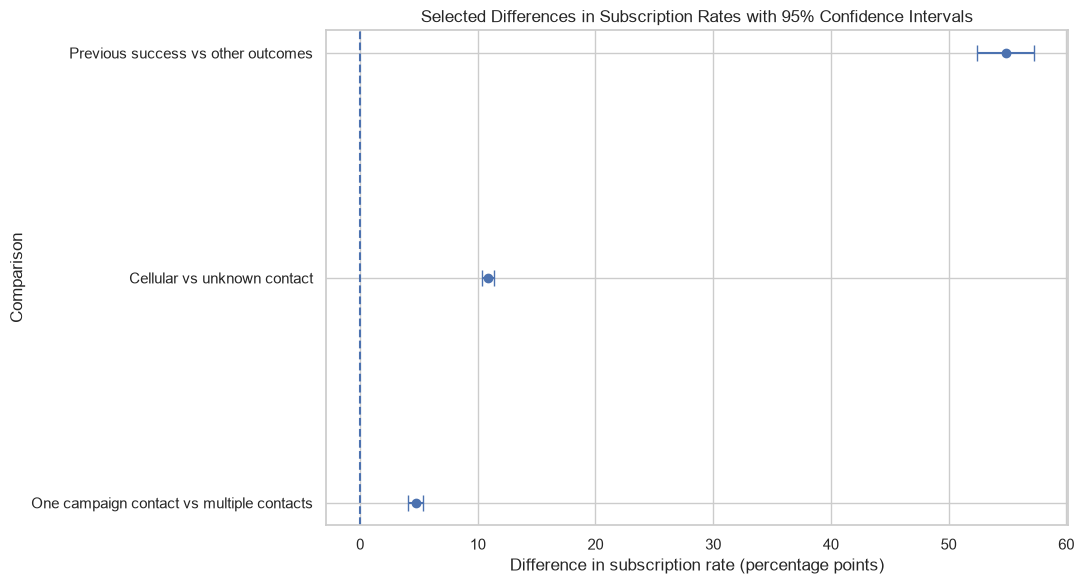

In [16]:
figure, axis = plt.subplots(figsize=(11, 6))

axis.errorbar(
    x=comparison_plot_data[
        "difference_percentage_points"
    ],
    y=comparison_plot_data["comparison"],
    xerr=np.vstack(
        [
            comparison_plot_data["lower_error"],
            comparison_plot_data["upper_error"],
        ]
    ),
    fmt="o",
    capsize=6,
)

axis.axvline(
    0,
    linestyle="--",
)

axis.set_title(
    "Selected Differences in Subscription Rates "
    "with 95% Confidence Intervals"
)
axis.set_xlabel(
    "Difference in subscription rate "
    "(percentage points)"
)
axis.set_ylabel("Comparison")

plt.tight_layout()
plt.show()

In [17]:
proportion_interpretations = (
    comparison_intervals[
        [
            "comparison",
            "group_a_rate_percentage",
            "group_b_rate_percentage",
            "difference_percentage_points",
            "ci_lower_percentage_points",
            "ci_upper_percentage_points",
        ]
    ]
    .copy()
)

proportion_interpretations[
    "interval_excludes_zero"
] = (
    (
        proportion_interpretations[
            "ci_lower_percentage_points"
        ] > 0
    )
    | (
        proportion_interpretations[
            "ci_upper_percentage_points"
        ] < 0
    )
)

display(proportion_interpretations)

,comparison,group_a_rate_percentage,group_b_rate_percentage,difference_percentage_points,ci_lower_percentage_points,ci_upper_percentage_points,interval_excludes_zero
0,Previous success vs other outcomes,64.725347,9.864989,54.860359,52.434927,57.285790,True
1,Cellular vs unknown contact,14.918900,4.070661,10.848240,10.317471,11.379009,True
2,One campaign contact vs multiple contacts,14.597583,9.860122,4.737461,4.107876,5.367046,True


### Selected Observational Comparisons

- Clients with a previous successful campaign outcome have a substantially higher observed subscription rate than clients with other previous outcomes.
- Cellular-contact records show a higher observed subscription rate than records with an unknown contact type.
- Clients contacted once during the current campaign show a higher observed subscription rate than clients contacted multiple times.

The confidence intervals for these selected differences exclude zero.

However, the groups were not randomly assigned. Differences may reflect selection effects, customer characteristics, previous interest, campaign strategy, or other confounding variables.

## 7. Statistical Significance versus Practical Significance

Statistical significance and practical importance answer different questions.

### Statistical significance

A small adjusted p-value indicates evidence against the null hypothesis under the assumptions of the statistical test.

### Practical significance

Effect size measures whether the observed relationship or group separation is large enough to matter in practice.

With a large dataset, very small effects may become statistically significant.

Therefore, decisions should consider:

- Adjusted p-values.
- Effect sizes.
- Confidence intervals.
- Segment size.
- Business cost.
- Operational feasibility.
- Feature availability at prediction time.

In [18]:
numerical_practical_summary = (
    numerical_results[
        [
            "analysis_name",
            "adjusted_p_value_bh",
            "reject_null_fdr_0_05",
            "rank_biserial_correlation",
            "effect_size_interpretation",
            "median_difference",
            "leakage_sensitive",
        ]
    ]
    .copy()
)

numerical_practical_summary[
    "statistically_significant_but_small_or_negligible"
] = (
    numerical_practical_summary[
        "reject_null_fdr_0_05"
    ]
    & numerical_practical_summary[
        "effect_size_interpretation"
    ].isin(["Negligible", "Small"])
)

display(numerical_practical_summary)

,analysis_name,adjusted_p_value_bh,reject_null_fdr_0_05,rank_biserial_correlation,effect_size_interpretation,median_difference,leakage_sensitive,statistically_significant_but_small_or_negligible
0,duration,0.000000,True,0.615191,Large,262.000000,True,False
1,pdays_previously_contacted,0.000000,True,-0.255166,Small,-51.000000,False,True
2,previous,0.000000,True,0.204607,Small,0.000000,False,True
3,balance,0.000000,True,0.180123,Small,316.000000,False,True
4,campaign,0.000000,True,-0.144668,Small,0.000000,False,True
5,age,0.062818,False,-0.015711,Negligible,-1.000000,False,False


### Example Interpretation

A feature may have an adjusted p-value below 0.05 while having only a negligible or small effect size.

In that case, the dataset provides evidence that the distributions differ, but the difference may have limited business value by itself.

This is why the project does not rank features using p-values alone.

## 8. Chi-Square Assumption Review

The Chi-square approximation relies on sufficiently large expected cell frequencies.

The analysis records:

- The minimum expected frequency.
- The number and percentage of expected cells below five.
- An assumption-warning flag.

A warning does not automatically invalidate the entire feature, but it indicates that the asymptotic Chi-square approximation should be interpreted carefully.

In [19]:
chi_square_assumption_review = (
    categorical_results[
        [
            "feature",
            "minimum_expected_frequency",
            "expected_cells_below_five",
            "expected_cells_below_five_percentage",
            "assumption_warning",
        ]
    ]
    .sort_values(
        [
            "assumption_warning",
            "expected_cells_below_five_percentage",
        ],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

display(chi_square_assumption_review)

,feature,minimum_expected_frequency,expected_cells_below_five,expected_cells_below_five_percentage,assumption_warning
0,poutcome,176.764040,0,0.000000,False
1,month,25.034748,0,0.000000,False
2,previously_contacted,965.943531,0,0.000000,False
3,contact,339.957842,0,0.000000,False
4,housing,"2,349.171861",0,0.000000,False
5,job,33.691624,0,0.000000,False
6,education,217.240782,0,0.000000,False
7,loan,847.437924,0,0.000000,False
8,marital,609.139877,0,0.000000,False
9,default,95.342616,0,0.000000,False


In [20]:
features_with_assumption_warning = (
    chi_square_assumption_review.loc[
        chi_square_assumption_review[
            "assumption_warning"
        ],
        "feature",
    ]
    .tolist()
)

print(
    "Features with a Chi-square assumption warning:",
    features_with_assumption_warning,
)

Features with a Chi-square assumption warning: []


## 9. Leakage-Sensitive Statistical Result

Call duration may show strong statistical and practical association with subscription.

This does not make it suitable for the primary model.

The key question is not only:

> Is the feature statistically associated with the target?

It is also:

> Is the feature available at the moment when the prediction must be made?

For pre-call customer targeting, duration is unavailable because it is only observed after the call ends.

In [21]:
duration_result = (
    numerical_results.loc[
        numerical_results[
            "analysis_name"
        ] == "duration"
    ]
    .reset_index(drop=True)
)

display(
    duration_result[
        [
            "analysis_name",
            "subscriber_median",
            "non_subscriber_median",
            "median_difference",
            "adjusted_p_value_bh",
            "rank_biserial_correlation",
            "effect_size_interpretation",
            "leakage_sensitive",
        ]
    ]
)

,analysis_name,subscriber_median,non_subscriber_median,median_difference,adjusted_p_value_bh,rank_biserial_correlation,effect_size_interpretation,leakage_sensitive
0,duration,426.000000,164.000000,262.000000,0.000000,0.615191,Large,True


In [22]:
assert len(duration_result) == 1
assert bool(
    duration_result.loc[
        0,
        "leakage_sensitive",
    ]
)

print(
    "Duration is retained for retrospective analysis "
    "but flagged for exclusion from the primary "
    "pre-call prediction model."
)

Duration is retained for retrospective analysis but flagged for exclusion from the primary pre-call prediction model.


## 10. Why This Is Not an A/B Test

This dataset records historical bank-marketing campaign outcomes.

It is not a randomized experiment because there is no evidence that customers were randomly assigned to:

- Contact channels.
- Campaign months.
- Numbers of contact attempts.
- Previous campaign outcomes.
- Customer demographic groups.

Therefore, the analysis can identify associations but cannot estimate causal treatment effects without stronger assumptions or an appropriate causal design.

### Example of a Future Bank A/B Test

The bank could randomly assign eligible customers to:

- **Control group:** current campaign message or contact strategy.
- **Treatment group:** a new message, call schedule, or offer presentation.

Before launching the experiment, the bank should define:

- Primary outcome.
- Minimum detectable effect.
- Required sample size.
- Eligibility rules.
- Randomization unit.
- Experiment duration.
- Guardrail metrics.
- Stopping rules.
- Analysis plan.

Randomization would help balance observed and unobserved customer characteristics between treatment groups.

## 11. Strongest Observed Statistical Relationships

The following tables summarize the strongest observed effects.

They are ranked using effect-size magnitude rather than p-value.

In [23]:
top_categorical_effects = (
    categorical_results[
        [
            "feature",
            "adjusted_p_value_bh",
            "cramers_v",
            "effect_size_interpretation",
            "reject_null_fdr_0_05",
            "assumption_warning",
        ]
    ]
    .sort_values(
        "cramers_v",
        ascending=False,
    )
    .head(5)
    .reset_index(drop=True)
)

display(top_categorical_effects)

,feature,adjusted_p_value_bh,cramers_v,effect_size_interpretation,reject_null_fdr_0_05,assumption_warning
0,poutcome,0.000000,0.311663,Moderate,True,False
1,month,0.000000,0.260237,Small,True,False
2,previously_contacted,0.000000,0.167263,Small,True,False
3,contact,0.000000,0.151355,Small,True,False
4,housing,0.000000,0.139173,Small,True,False


In [24]:
top_numerical_effects = (
    numerical_results[
        [
            "analysis_name",
            "adjusted_p_value_bh",
            "rank_biserial_correlation",
            "absolute_effect_size",
            "effect_size_interpretation",
            "median_direction",
            "leakage_sensitive",
        ]
    ]
    .sort_values(
        "absolute_effect_size",
        ascending=False,
    )
    .head(5)
    .reset_index(drop=True)
)

display(top_numerical_effects)

,analysis_name,adjusted_p_value_bh,rank_biserial_correlation,absolute_effect_size,effect_size_interpretation,median_direction,leakage_sensitive
0,duration,0.000000,0.615191,0.615191,Large,Higher among subscribers,True
1,pdays_previously_contacted,0.000000,-0.255166,0.255166,Small,Lower among subscribers,False
2,previous,0.000000,0.204607,0.204607,Small,Equal medians,False
3,balance,0.000000,0.180123,0.180123,Small,Higher among subscribers,False
4,campaign,0.000000,-0.144668,0.144668,Small,Equal medians,False


## 12. Final Statistical-Analysis Validation

The following checks confirm that the test outputs, confidence intervals, multiple-testing corrections, and effect-size values are internally consistent.

In [25]:
assert len(data) == 45_211
assert int(data[TARGET_COLUMN].sum()) == 5_289

assert len(categorical_results) == len(
    CATEGORICAL_FEATURES
)

assert len(numerical_results) == len(
    NUMERICAL_TEST_SPECIFICATIONS
)

assert len(overall_interval) == 1
assert len(comparison_intervals) == 3

assert categorical_results[
    "p_value"
].between(0, 1).all()

assert categorical_results[
    "adjusted_p_value_bh"
].between(0, 1).all()

assert numerical_results[
    "p_value"
].between(0, 1).all()

assert numerical_results[
    "adjusted_p_value_bh"
].between(0, 1).all()

assert categorical_results[
    "cramers_v"
].between(0, 1).all()

assert numerical_results[
    "rank_biserial_correlation"
].between(-1, 1).all()

assert (
    overall_interval.loc[
        0,
        "ci_lower_percentage",
    ]
    <= overall_interval.loc[
        0,
        "estimated_subscription_rate_percentage",
    ]
    <= overall_interval.loc[
        0,
        "ci_upper_percentage",
    ]
)

assert (
    comparison_intervals[
        "ci_lower_percentage_points"
    ]
    <= comparison_intervals[
        "difference_percentage_points"
    ]
).all()

assert (
    comparison_intervals[
        "difference_percentage_points"
    ]
    <= comparison_intervals[
        "ci_upper_percentage_points"
    ]
).all()

assert bool(
    numerical_results.loc[
        numerical_results[
            "analysis_name"
        ] == "duration",
        "leakage_sensitive",
    ].iloc[0]
)

print(
    "All statistical notebook analyses "
    "and validation checks passed successfully."
)

All statistical notebook analyses and validation checks passed successfully.


## 13. Statistical Analysis Summary

The statistical analysis evaluated categorical associations, numerical group differences, confidence intervals, and practical effect sizes.

Main methodological conclusions:

- Chi-square tests were used for categorical associations with subscription.
- Cramér's V was reported because p-values alone do not describe association strength.
- Mann–Whitney U tests were used for highly skewed numerical variables.
- Rank-biserial correlation quantified numerical effect sizes and their direction.
- Benjamini–Hochberg correction controlled the False Discovery Rate within the categorical and numerical test families.
- The overall subscription rate was reported with a Wilson score confidence interval.
- Selected group-rate differences were reported in percentage points with confidence intervals.
- Statistical significance was separated from practical significance.
- Call duration was statistically informative but remained unsuitable for the primary pre-call model because of temporal data leakage.
- The historical campaign data was treated as observational data rather than an A/B test.
- Reported associations should not be interpreted as causal effects.

The project is ready to proceed to feature engineering, preprocessing pipelines, and machine-learning model development.